# Tugas Proyek IF3211 - Domain-Specific Computation
## Deteksi Transisi Respirasi Aerobik-Anaerobik Berdasarkan Respiratory Exchange Ratio (RER) Menggunakan Arsitektur Long Short-Term Memory (LSTM)

**Anggota Kelompok:**
* 18223012 - Wilson
* 18223020 - Brandon Theodore Ferrinov
* 18223038 - Rafli Dwi Nugraga
* 18223090 - Derick Amadeus Budiono


Sumber Dataset : http://physionet.org/content/treadmill-exercise-cardioresp/1.0.1/

# 1. ***Library Import***

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 2. ***LOAD DATA & PEMBUATAN TARGET***

In [11]:
df = pd.read_csv('datasets/test_measure.csv')
df_subject = df[df['ID_test'] == '2_1'].copy()

# Target Fisiologis: RER = VCO2 / VO2
df_subject['RER'] = df_subject['VCO2'] / df_subject['VO2']
df_subject['Anaerobic_Label'] = (df_subject['RER'] >= 1.0).astype(int)

# 3. ***EXPLORATORY DATA ANALYSIS (EDA)***

Melakukan EDA


C:\Users\ASUS\AppData\Local\Temp\ipykernel_33880\2846717685.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Anaerobic_Label', data=df_subject, palette='Set2')


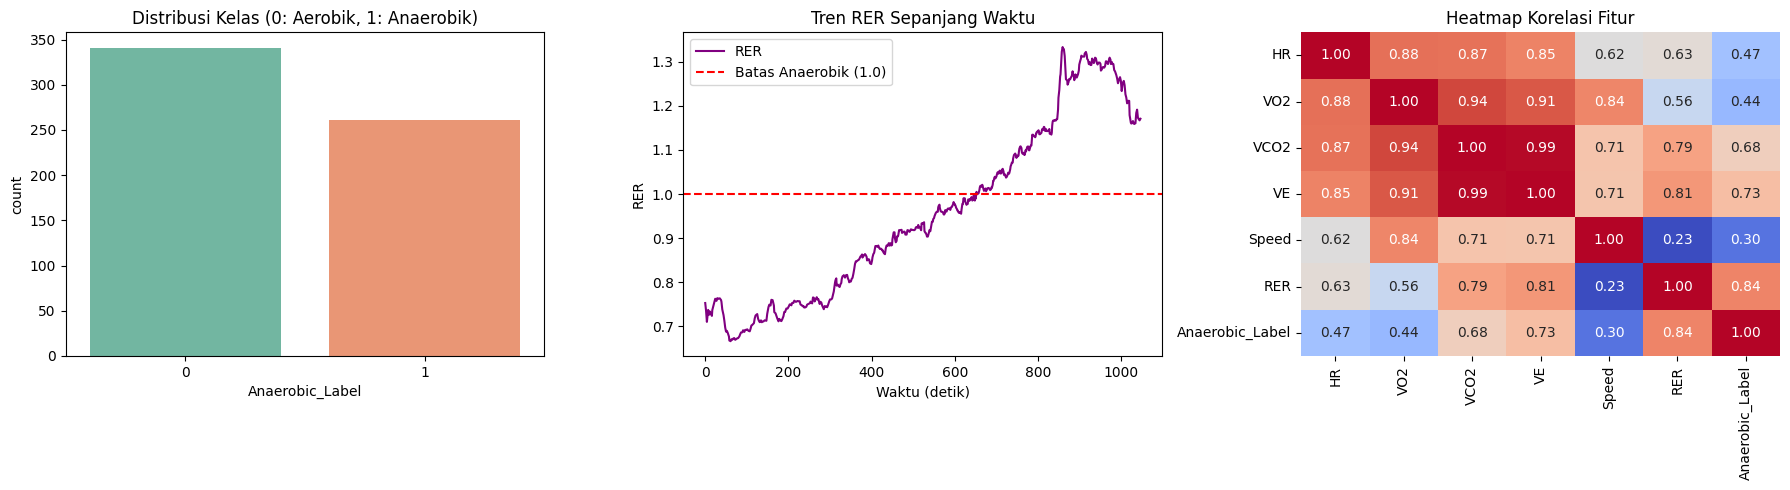

In [12]:
print("Melakukan EDA")

plt.figure(figsize=(18, 5))

# A. Distribusi Kelas Target
plt.subplot(1, 3, 1)
sns.countplot(x='Anaerobic_Label', data=df_subject, palette='Set2')
plt.title('Distribusi Kelas (0: Aerobik, 1: Anaerobik)')

# B. Tren RER terhadap Waktu
plt.subplot(1, 3, 2)
plt.plot(df_subject['time'], df_subject['RER'], color='purple', label='RER')
plt.axhline(y=1.0, color='r', linestyle='--', label='Batas Anaerobik (1.0)')
plt.title('Tren RER Sepanjang Waktu')
plt.xlabel('Waktu (detik)')
plt.ylabel('RER')
plt.legend()

# C. Heatmap Korelasi Fitur
plt.subplot(1, 3, 3)
corr_cols = ['HR', 'VO2', 'VCO2', 'VE', 'Speed', 'RER', 'Anaerobic_Label']
sns.heatmap(df_subject[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Heatmap Korelasi Fitur')

plt.tight_layout()
plt.show()

# 4. ***ADVANCED FEATURE ENGINEERING & PREPROCESSING***

In [13]:
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas to use its Series/DataFrame methods for NaN handling

# Menambahkan Fitur Moving Average (MA) untuk menghaluskan noise sensor (window=3)
df_subject['HR_MA'] = df_subject['HR'].rolling(window=3, min_periods=1).mean()
df_subject['VE_MA'] = df_subject['VE'].rolling(window=3, min_periods=1).mean()

features = ['HR', 'HR_MA', 'VO2', 'VCO2', 'VE', 'VE_MA', 'Speed']
data_X = df_subject[features].values
data_Y = df_subject['Anaerobic_Label'].values

# Normalisasi
scaler = MinMaxScaler(feature_range=(0, 1))
data_X_scaled = scaler.fit_transform(data_X)

# Sliding Window
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_seq, y_seq = create_sequences(data_X_scaled, data_Y, time_steps)

# --- Penanganan NaN di X_seq sebelum Train-Test Split ---
# Karena X_seq adalah numpy array, kita bisa konversi sementara ke pandas DataFrame untuk fillna
# Kemudian konversi kembali ke numpy array
original_shape = X_seq.shape
X_seq_reshaped_2d = X_seq.reshape(-1, original_shape[-1]) # reshape to 2D for pandas fillna

X_seq_df = pd.DataFrame(X_seq_reshaped_2d)
X_seq_df = X_seq_df.ffill() # Forward-fill
X_seq_df = X_seq_df.bfill() # Backward-fill any remaining NaNs (e.g., at the start)

# Pastikan tidak ada NaN yang tersisa, jika ada kemungkinan, isi dengan 0 atau rata-rata
if X_seq_df.isnull().sum().sum() > 0:
    X_seq_df = X_seq_df.fillna(0) # Fallback: fill any remaining with 0

X_seq = X_seq_df.values.reshape(original_shape) # Reshape back to original 3D shape

print(f"NaN di X_seq setelah penanganan: {np.isnan(X_seq).sum()}")
print(f"Inf di X_seq setelah penanganan: {np.isinf(X_seq).sum()}")

# Split Training dan Testing (Sequential, tanpa shuffle)
# Menggunakan Stratified Train-Test Split untuk menjaga proporsi kelas
# Pastikan y_seq tidak kosong dan memiliki lebih dari satu kelas
if len(np.unique(y_seq)) > 1:
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)
else:
    # Fallback if only one class is present in y_seq (should be handled earlier if possible)
    print("Warning: Only one class found in y_seq. Cannot perform stratified split.")
    split_idx = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

NaN di X_seq setelah penanganan: 0
Inf di X_seq setelah penanganan: 0


# 5. ***ADVANCED MODEL ARCHITECTURE (Bi-LTSM)***

In [14]:
# Membangun ulang model untuk memastikan bobot diinisialisasi ulang
model = Sequential([
    # Layer Bidirectional LSTM
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    # Layer Bidirectional LSTM kedua
    Bidirectional(LSTM(32, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),

    # Output Layer
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Menggunakan Adam optimizer dengan gradient clipping
# Ini membantu mencegah exploding gradients yang sering terjadi pada RNN
optimizer = Adam(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks: Pintar dalam mengatur epoch dan learning rate
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

print("\nMemulai Training Model Advanced...")
history = model.fit(
    X_train, y_train,
    epochs=100, # Bisa diset tinggi karena ada EarlyStopping
    batch_size=16,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


Memulai Training Model Advanced...
Epoch 1/100


27/27 [==============================] - 8s 68ms/step - loss: 0.3389 - accuracy: 0.8376 - val_loss: 0.6380 - val_accuracy: 0.9792 - lr: 0.0010
Epoch 2/100
27/27 [==============================] - 0s 12ms/step - loss: 0.1622 - accuracy: 0.9341 - val_loss: 0.5977 - val_accuracy: 0.9583 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 0s 10ms/step - loss: 0.1296 - accuracy: 0.9529 - val_loss: 0.5652 - val_accuracy: 0.8333 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 0s 9ms/step - loss: 0.1296 - accuracy: 0.9482 - val_loss: 0.5041 - val_accuracy: 0.8750 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 0s 11ms/step - loss: 0.1255 - accuracy: 0.9553 - val_loss: 0.4692 - val_accuracy: 0.8333 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 0s 10ms/step - loss: 0.1161 - accuracy: 0.9576 - val_loss: 0.4109 - val_accuracy: 0.8542 - lr: 0.0010
Epoch 7/100
27/27 [==============

# 6. ***EVALUASI***


Akurasi Testing (Advanced Model): 95.80%
4/4 [==============================] - 2s 4ms/step

--- Classification Report ---
               precision    recall  f1-score   support

  Aerobik (0)       1.00      0.93      0.96        67
Anaerobik (1)       0.91      1.00      0.95        52

     accuracy                           0.96       119
    macro avg       0.96      0.96      0.96       119
 weighted avg       0.96      0.96      0.96       119



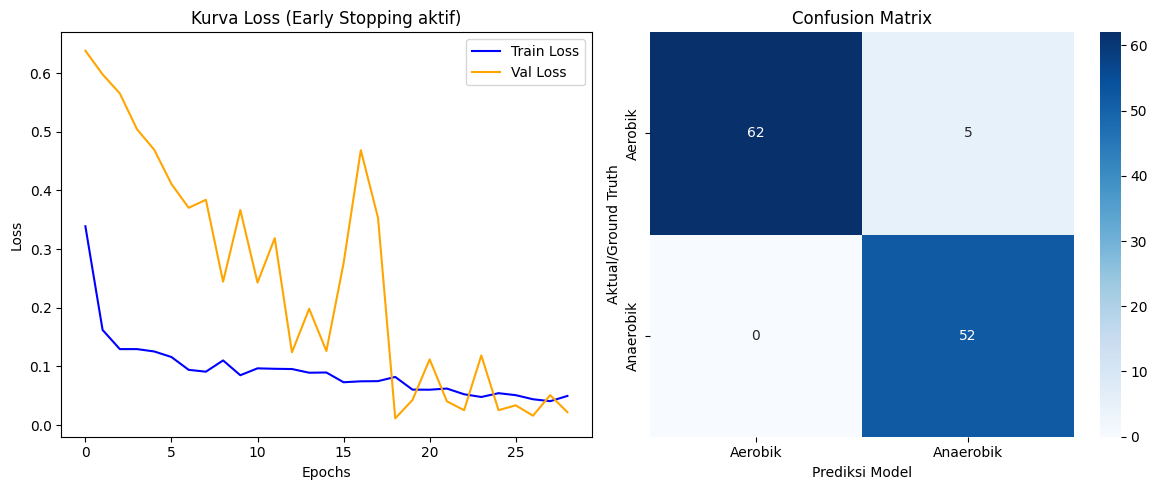

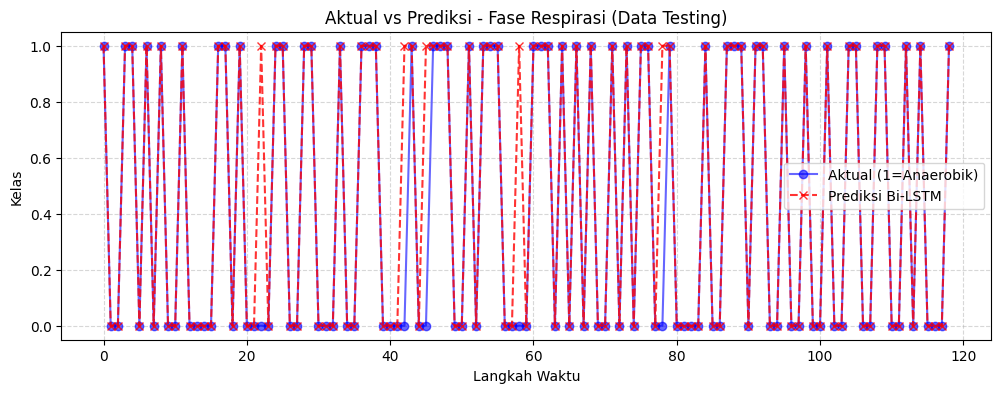

In [15]:
# Evaluasi Akurasi
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAkurasi Testing (Advanced Model): {test_acc * 100:.2f}%")

# Prediksi untuk Confusion Matrix & Classification Report
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Aerobik (0)', 'Anaerobik (1)']))

# Visualisasi Loss & Confusion Matrix
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Kurva Loss (Early Stopping aktif)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Aerobik', 'Anaerobik'], yticklabels=['Aerobik', 'Anaerobik'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual/Ground Truth')

plt.tight_layout()
plt.show()

# Grafik Prediksi vs Aktual
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Aktual (1=Anaerobik)', color='blue', marker='o', alpha=0.6)
plt.plot(y_pred, label='Prediksi Bi-LSTM', color='red', linestyle='--', marker='x', alpha=0.8)
plt.title('Aktual vs Prediksi - Fase Respirasi (Data Testing)')
plt.xlabel('Langkah Waktu')
plt.ylabel('Kelas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Menangani Ketidakseimbangan Kelas dengan Class Weights

Dari hasil evaluasi sebelumnya, terlihat bahwa model cenderung memprediksi kelas mayoritas (Aerobik/0) secara eksklusif. Ini adalah masalah umum pada dataset yang tidak seimbang (class imbalance), meskipun sudah dilakukan stratified split.

Untuk mengatasi ini, kita dapat menggunakan **class weights** saat melatih model. Class weights memberikan bobot yang lebih tinggi pada sampel dari kelas minoritas (Anaerobik/1), sehingga model akan lebih 'memperhatikan' kelas ini dan dihukum lebih berat jika salah memprediksinya.

In [16]:
from sklearn.utils import class_weight

# Hitung class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

Class Weights: {0: 0.8958333333333334, 1: 1.131578947368421}


### Melatih Ulang Model dengan Class Weights

Sekarang, kita akan melatih ulang model dengan `class_weights` yang telah dihitung. Ini diharapkan dapat membantu model belajar untuk memprediksi kelas minoritas dengan lebih baik.


Memulai Training Model Advanced dengan Class Weights (dengan Gradient Clipping Norm)...
Epoch 1/100
27/27 [==============================] - 7s 50ms/step - loss: 0.2355 - accuracy: 0.9012 - val_loss: 0.6117 - val_accuracy: 0.9792 - lr: 0.0010
Epoch 2/100
27/27 [==============================] - 0s 8ms/step - loss: 0.1436 - accuracy: 0.9506 - val_loss: 0.5615 - val_accuracy: 0.8333 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 0s 10ms/step - loss: 0.1277 - accuracy: 0.9459 - val_loss: 0.5146 - val_accuracy: 0.8333 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 0s 8ms/step - loss: 0.1176 - accuracy: 0.9600 - val_loss: 0.4609 - val_accuracy: 0.8333 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 0s 8ms/step - loss: 0.1021 - accuracy: 0.9576 - val_loss: 0.4126 - val_accuracy: 0.8333 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 0s 10ms/step - loss: 0.0995 - accuracy: 0.9600 - val_loss: 0.3577 - val_accuracy: 0.83

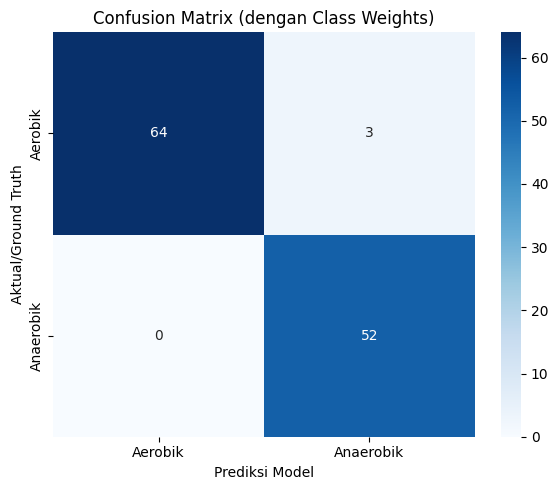

In [17]:
model_weighted = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(32, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Menggunakan Adam optimizer dengan gradient clipping (clipnorm)
# clipnorm adalah alternatif untuk clipvalue dan terkadang lebih stabil
optimizer_weighted = Adam(learning_rate=0.001, clipnorm=1.0)

model_weighted.compile(optimizer=optimizer_weighted, loss='binary_crossentropy', metrics=['accuracy'])

# Re-instantiate callbacks for a fresh start with the weighted model training
early_stopping_weighted = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
lr_scheduler_weighted = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

print("\nMemulai Training Model Advanced dengan Class Weights (dengan Gradient Clipping Norm)...")
history_weighted = model_weighted.fit(
    X_train,
    y_train,
    epochs=100, # Bisa diset tinggi karena ada EarlyStopping
    batch_size=16,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping_weighted, lr_scheduler_weighted],
    class_weight=class_weights_dict, # Tambahkan class_weight di sini
    verbose=1
)

# Evaluasi setelah melatih dengan class weights
test_loss_weighted, test_acc_weighted = model_weighted.evaluate(X_test, y_test, verbose=0)
print(f"\nAkurasi Testing (Model dengan Class Weights): {test_acc_weighted * 100:.2f}%")

y_pred_probs_weighted = model_weighted.predict(X_test)
y_pred_weighted = (y_pred_probs_weighted >= 0.5).astype(int).flatten()

print("\n--- Classification Report (dengan Class Weights) ---")
print(classification_report(y_test, y_pred_weighted, target_names=['Aerobik (0)', 'Anaerobik (1)']))

# Visualisasi Confusion Matrix setelah class weights
plt.figure(figsize=(6, 5))
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues', xticklabels=['Aerobik', 'Anaerobik'], yticklabels=['Aerobik', 'Anaerobik'])
plt.title('Confusion Matrix (dengan Class Weights)')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual/Ground Truth')
plt.tight_layout()
plt.show()

### Pemeriksaan Integritas Data (NaN/Inf)

Karena model terus-menerus menghasilkan `loss: nan`, ini bisa jadi indikasi adanya nilai `NaN` atau `inf` di data input atau target yang digunakan untuk training. Mari kita periksa `X_train` dan `y_train`.

In [18]:
print(f"NaN di X_train: {np.isnan(X_train).sum()}")
print(f"Inf di X_train: {np.isinf(X_train).sum()}")
print(f"NaN di y_train: {np.isnan(y_train).sum()}")
print(f"Inf di y_train: {np.isinf(y_train).sum()}")

if np.isnan(X_train).sum() > 0 or np.isinf(X_train).sum() > 0 or \
   np.isnan(y_train).sum() > 0 or np.isinf(y_train).sum() > 0:
    print("\nPERINGATAN: Ditemukan nilai NaN atau Inf di data training. Ini perlu diatasi!")
else:
    print("\nTidak ditemukan nilai NaN atau Inf di data training. Masalah mungkin ada di hyperparameter atau arsitektur model.")

NaN di X_train: 0
Inf di X_train: 0
NaN di y_train: 0
Inf di y_train: 0

Tidak ditemukan nilai NaN atau Inf di data training. Masalah mungkin ada di hyperparameter atau arsitektur model.
